# DATASET TITLE: Spotify Track Popularity and Release Patterns Analysis

#### NAME: <Your Name>
#### SECTION: CSE 2
#### ENROLLMENT NUMBER: <Your Enrollment>
#### COURSE: Data Analytics Using Python
#### Course Code: DAP1101
#### Institution: BML Munjal University
#### Date of Submission: <Submission Date>

#### ABOUT PROJECT:
This mini project analyzes Spotify tracks to understand factors influencing popularity and release patterns using a single local dataset. It follows an academic workflow including problem definition, data cleaning, exploratory data analysis, statistical testing, predictive modeling, and conclusions.

#### Dataset Source and Overview
- Source: Local Spotify-curated dataset derived from Spotify Web API (recent releases)
- File: `spotify_data clean.csv` (same folder)
- Variables include track and artist identifiers, popularity scores, explicit flags, followers, genres, album metadata, and durations
- Types: numerical (popularity, followers, duration), categorical (explicit, album_type, genres), date (`album_release_date`)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
np.random.seed(42)
random.seed(42)
print('pandas', pd.__version__)
print('numpy', np.__version__)
print('seaborn', sns.__version__)

pandas 2.2.2
numpy 1.26.4
seaborn 0.13.2


In [12]:
df = pd.read_csv('spotify_data clean.csv')
df.shape

(8582, 15)

In [13]:
display(df.head())
df.info()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), object(8)
memory usag

#### Data Cleaning and Preparation

In [14]:
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')
df['explicit'] = df['explicit'].astype(str).str.lower().map({'true': True, 'false': False})
num_cols = ['track_popularity','artist_popularity','artist_followers','track_duration_min','track_number','album_total_tracks']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
today = pd.Timestamp.today().normalize()
df['release_age_days'] = (today - df['album_release_date']).dt.days
df['release_weekday'] = df['album_release_date'].dt.day_name()
df.loc[df['release_weekday'].isna(), 'release_weekday'] = 'Unknown'
df['log_followers'] = np.log1p(df['artist_followers'])
df = df.drop_duplicates(subset=['track_id'])
genres = df['artist_genres'].astype(str).str.lower()
genres = genres.replace({'n/a': np.nan})
tokens = genres.dropna().str.split(',').explode().str.strip()
top_tokens = tokens.value_counts().head(20).index.tolist()
def sanitize_token(t):
    return t.replace(' ', '_').replace('/', '_').replace('-', '_')
for t in top_tokens:
    col = 'genre_' + sanitize_token(t)
    df[col] = df['artist_genres'].astype(str).str.contains(t, case=False, na=False).astype(int)

#### Exploratory Data Analysis (EDA)

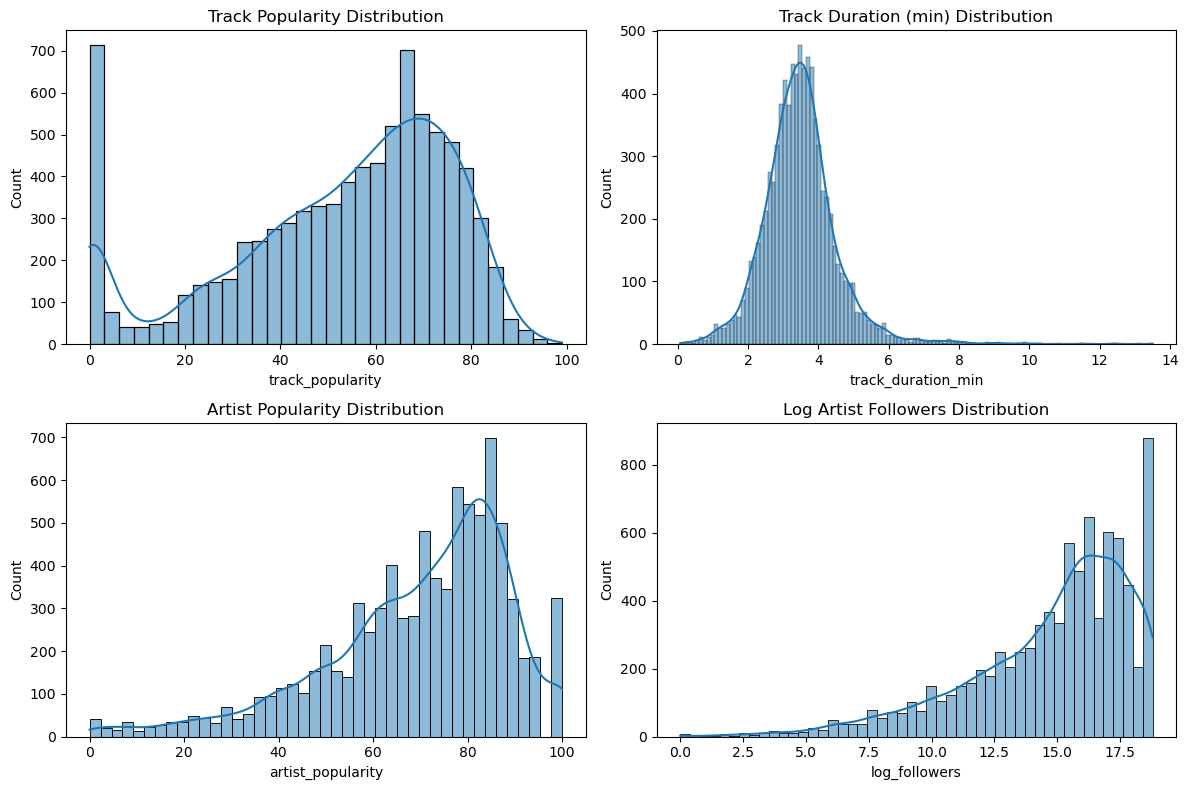

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['track_popularity'].dropna(), kde=True, ax=axes[0,0])
axes[0,0].set_title('Track Popularity Distribution')
sns.histplot(df['track_duration_min'].dropna(), kde=True, ax=axes[0,1])
axes[0,1].set_title('Track Duration (min) Distribution')
sns.histplot(df['artist_popularity'].dropna(), kde=True, ax=axes[1,0])
axes[1,0].set_title('Artist Popularity Distribution')
sns.histplot(df['log_followers'].dropna(), kde=True, ax=axes[1,1])
axes[1,1].set_title('Log Artist Followers Distribution')
plt.tight_layout()

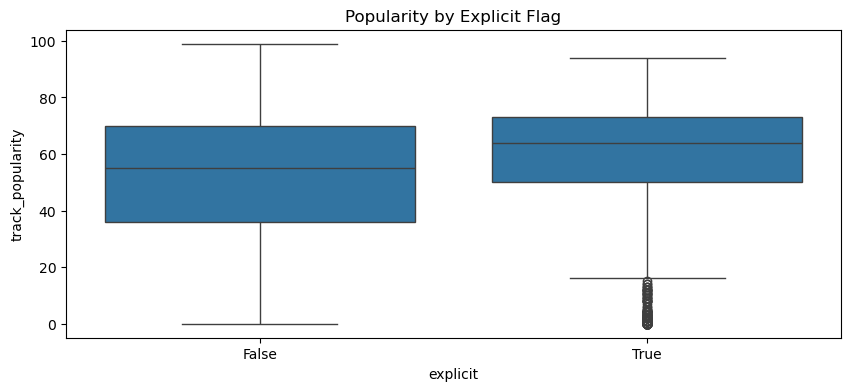

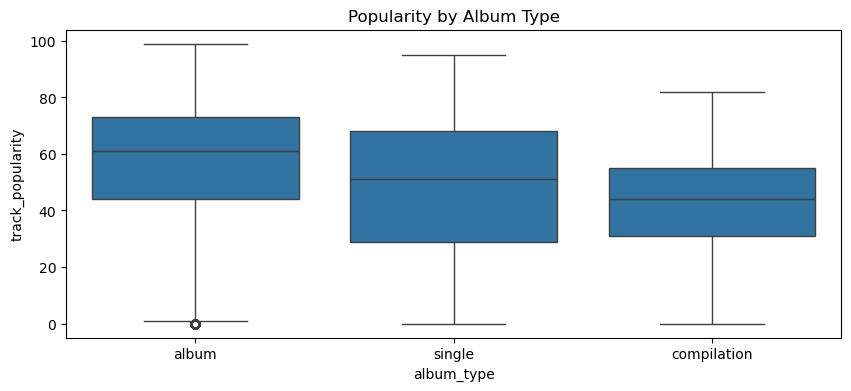

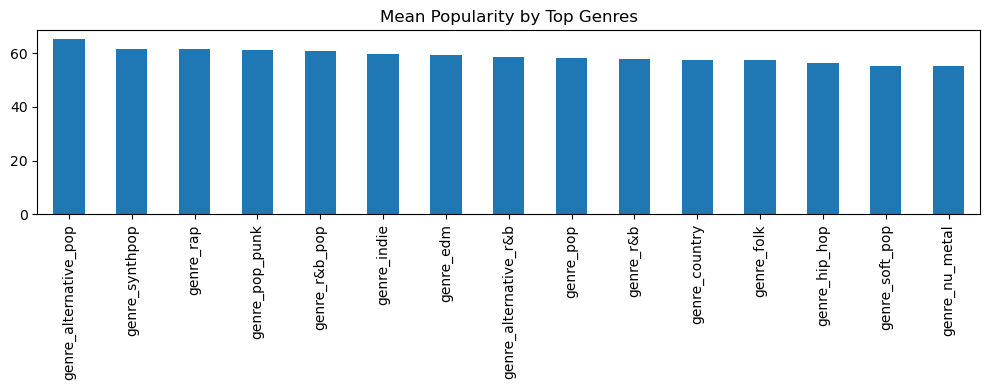

In [16]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='explicit', y='track_popularity')
plt.title('Popularity by Explicit Flag')
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='album_type', y='track_popularity')
plt.title('Popularity by Album Type')
plt.figure(figsize=(10,4))
mean_pop_by_genre = {}
for t in top_tokens:
    col = 'genre_' + t.replace(' ', '_').replace('/', '_').replace('-', '_')
    if col in df.columns:
        mean_pop_by_genre[col] = df.loc[df[col]==1, 'track_popularity'].mean()
pd.Series(mean_pop_by_genre).sort_values(ascending=False).head(15).plot(kind='bar')
plt.title('Mean Popularity by Top Genres')
plt.tight_layout()

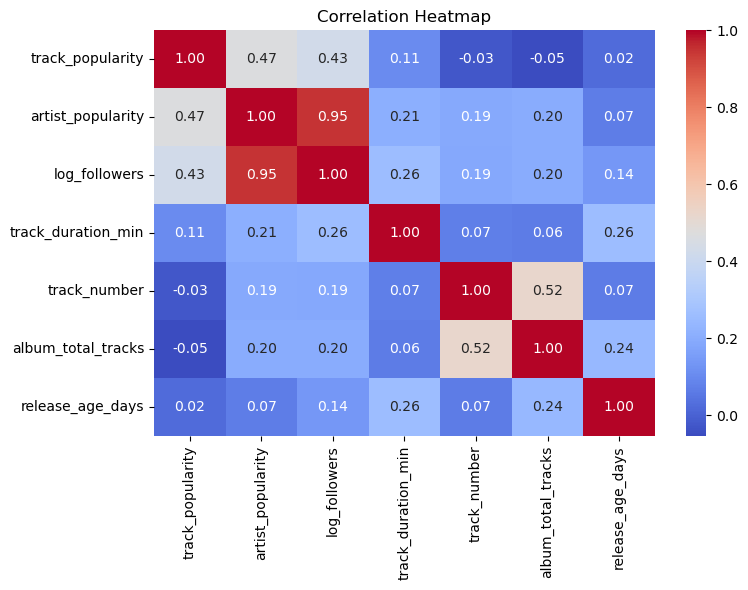

In [17]:
corr_cols = ['track_popularity','artist_popularity','log_followers','track_duration_min','track_number','album_total_tracks','release_age_days']
plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()

In [18]:
desc = df[['track_popularity','track_duration_min','artist_popularity','log_followers']].describe()
skew = df[['track_popularity','track_duration_min','artist_popularity','log_followers']].skew()
kurt = df[['track_popularity','track_duration_min','artist_popularity','log_followers']].kurt()
display(desc)
display(pd.DataFrame({'skew':skew,'kurtosis':kurt}))

,track_popularity,track_duration_min,artist_popularity,log_followers
count,8582.000000,8582.000000,8582.000000,8582.000000
mean,52.356211,3.492805,69.730016,14.773042
std,23.816076,1.057970,19.645979,3.254107
min,0.000000,0.070000,0.000000,0.000000
25%,39.000000,2.880000,60.000000,13.044014
50%,58.000000,3.445000,74.000000,15.624708
75%,71.000000,3.990000,84.000000,17.120655
max,99.000000,13.510000,100.000000,18.795976


,skew,kurtosis
track_popularity,-0.784844,-0.237541
track_duration_min,1.284686,7.045769
artist_popularity,-1.039266,1.026035
log_followers,-1.194703,1.342490


#### Statistical Analysis and Hypothesis Testing

In [19]:
group_explicit = df.loc[df['explicit']==True, 'track_popularity'].dropna()
group_clean = df.loc[df['explicit']==False, 'track_popularity'].dropna()
t_stat, p_val = stats.ttest_ind(group_explicit, group_clean, equal_var=False)
n1 = group_explicit.shape[0]
n2 = group_clean.shape[0]
m1 = group_explicit.mean()
m2 = group_clean.mean()
s1 = group_explicit.std(ddof=1)
s2 = group_clean.std(ddof=1)
ci1 = stats.t.interval(0.95, df=n1-1, loc=m1, scale=s1/np.sqrt(n1))
ci2 = stats.t.interval(0.95, df=n2-1, loc=m2, scale=s2/np.sqrt(n2))
group_type_means = df[['album_type','track_popularity']].dropna().groupby('album_type').mean()['track_popularity']
display({'t_stat': t_stat, 'p_value': p_val, 'explicit_mean_CI': ci1, 'clean_mean_CI': ci2, 'album_type_mean_popularity': group_type_means.to_dict()})

{'t_stat': 12.877417966165538,
 'p_value': 3.3481157615062294e-37,
 'explicit_mean_CI': (56.877464135092474, 58.75940737328741),
 'clean_mean_CI': (49.94494698172833, 51.120331227783645),
 'album_type_mean_popularity': {'album': 55.65505464480874,
  'compilation': 40.51282051282051,
  'single': 46.35646687697161}}

#### Modeling and Validation (Regression)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


{'cv_mean_r2': 0.36330672558241295,
 'cv_std_r2': 0.026736649434832182,
 'test_R2': 0.4226530556663134,
 'test_RMSE': 18.524253941482407,
 'test_MAE': 13.192169675791108}

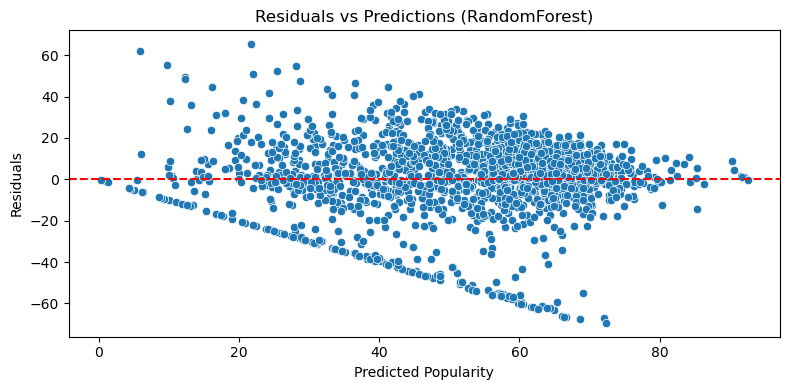

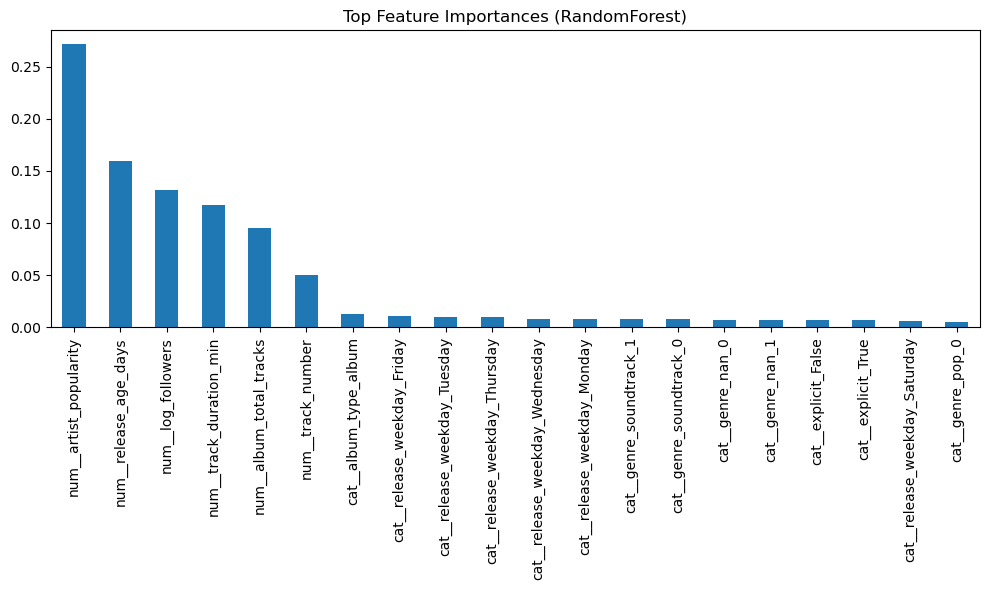

In [20]:
from sklearn.ensemble import RandomForestRegressor
# Random Forest pipeline for popularity prediction
target = 'track_popularity'
genre_cols = [c for c in df.columns if c.startswith('genre_')]
numeric_features = ['artist_popularity','log_followers','track_duration_min','track_number','album_total_tracks','release_age_days']
categorical_features = ['explicit','album_type','release_weekday'] + genre_cols
X = df[numeric_features + categorical_features]
y = df[target]
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Preprocessing
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocess = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, categorical_features)])
# Model and cross-validation
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
pipe = Pipeline(steps=[('preprocess', preprocess), ('model', rf)])
scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2')
# Fit and evaluate
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
display({'cv_mean_r2': float(np.mean(scores)), 'cv_std_r2': float(np.std(scores)), 'test_R2': r2, 'test_RMSE': rmse, 'test_MAE': mae})
# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predictions (RandomForest)')
plt.xlabel('Predicted Popularity')
plt.ylabel('Residuals')
plt.tight_layout()
# Feature importances from the fitted model
pre = pipe.named_steps['preprocess']
feature_names = pre.get_feature_names_out()
importances = pipe.named_steps['model'].feature_importances_
imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
imp.plot(kind='bar')
plt.title('Top Feature Importances (RandomForest)')
plt.tight_layout()

#### Interpretation and Inference
Summarize how explicitness, album type, genre tokens, and temporal features relate to popularity; interpret model metrics and importance patterns; discuss implications and limitations such as absence of audio features.

#### Conclusion
Provide final academic summary of findings, limitations, and future improvements.